# Planning-Agent Evaluation — Eval-Only (score cached plans)

Running the planning agent across 10 repeats × 15 tasks × 8 configs is expensive.
This notebook skips generation entirely: it loads the **already-recorded** planner
outputs from `outputs/ablation_raw_results.csv` and applies the **exact same
deterministic evaluation** as `planning_eval_refine.ipynb`:

$$\text{PlanScore} = \text{OrderPreservation} \times \text{ContentF1}$$

Pipeline:
1. **Parse** each recorded `plan_text` (canonical `📋 BREAKDOWN` numbered list) into a
   normalized ` → `-joined step string — done *deterministically* with regex (no LLM
   call), since the recorded plans are already fully structured.
2. **Ground truth** = the `reference_steps` workflow shipped in `planning_requests.csv`,
   joined per `task_id`.
3. **Embed** every unique step once (OpenAI `text-embedding-3-large`), calibrate the
   match threshold τ (Youden's *J*), and score every plan by Hungarian step matching.
4. **Statistics** (Kruskal–Wallis → pairwise Mann–Whitney U → Holm) and publication
   plots across the 8 `P-L-E` factorial configurations.

The only external cost is embedding the unique step phrases once.

## 1. Setup & imports

In [1]:
import sys
import re
import json
import time
import ast
import warnings
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.optimize import linear_sum_assignment
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

warnings.filterwarnings("ignore")

# --- Locate the project root (dir containing both app/ and backend/) ---------
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR
while PROJECT_ROOT != PROJECT_ROOT.parent and not (
    (PROJECT_ROOT / "app").is_dir() and (PROJECT_ROOT / "backend").is_dir()
):
    PROJECT_ROOT = PROJECT_ROOT.parent
if not ((PROJECT_ROOT / "app").is_dir() and (PROJECT_ROOT / "backend").is_dir()):
    raise RuntimeError(f"Could not locate project root from {CURRENT_DIR}")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from app.config import OPENAI_API_KEY
assert OPENAI_API_KEY, "OPENAI_API_KEY is required (used only for step embeddings)."

ABLATION_DIR = PROJECT_ROOT / "analysis" / "Ablation"
RAW_RESULTS_CSV = ABLATION_DIR / "outputs" / "ablation_raw_results.csv"
OUTPUT_DIR = ABLATION_DIR / "outputs" / "eval_only"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("raw results :", RAW_RESULTS_CSV)
print("output dir  :", OUTPUT_DIR)

raw results : /Users/dinhu955/Desktop/RepurAgent/repuragent-web/analysis/Ablation/outputs/ablation_raw_results.csv
output dir  : /Users/dinhu955/Desktop/RepurAgent/repuragent-web/analysis/Ablation/outputs/eval_only


In [2]:
# ------------------------- publication plotting theme ----------------------- #
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 8,
    'axes.titlesize': 9,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'lines.linewidth': 1.0,
    'patch.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'svg.fonttype': 'none',
    'pdf.fonttype': 42,
})
sns.set_theme(style="ticks")
pd.set_option("display.max_colwidth", 160)

## 2. Load recorded plans & parse `plan_text` deterministically

Each recorded `plan_text` follows the canonical format:

```
📋 BREAKDOWN:
1. [agent] <Title>: <objective>. Output: <expected output>.
2. ...

📋 Note for success: ...
Please review this plan. ...
```

We extract the **concise title** of each numbered step (the text after the
`[agent]` tag, up to the first colon / `Output:`) and join them with ` → ` — the
same normalized granularity as the ground-truth `reference_steps`. Non-numbered
lines (the `Note for success` and approval prompt) are ignored.

In [3]:
_STEP_RE = re.compile(r'^\s*(\d+)[.)]\s*(.*)$')
_AGENT_RE = re.compile(r'^\[[^\]]+\]\s*')
_OUTPUT_RE = re.compile(r'(?i)\s*output\s*[:\-]')


def parse_plan_text(text: str) -> list[str]:
    """Canonical BREAKDOWN text -> ordered list of concise step titles."""
    if not isinstance(text, str) or not text.strip():
        return []
    steps = []
    for line in text.splitlines():
        m = _STEP_RE.match(line)
        if not m:
            continue                                  # skip Note/approval/blank lines
        body = _AGENT_RE.sub('', m.group(2).strip())  # drop leading [agent]
        title = body.split(':', 1)[0].strip()         # title before first colon
        title = _OUTPUT_RE.split(title)[0].strip()     # guard against inline 'Output:'
        title = title.rstrip('.').strip()
        if title:
            steps.append(title)
    return steps


raw = pd.read_csv(RAW_RESULTS_CSV)
print(f"loaded {len(raw)} recorded plans | configs: {sorted(raw['config_label'].unique())}")

# Ground truth: reference_steps per task_id from the request dataset.
tasks_df = pd.read_csv(ABLATION_DIR / "planning_requests.csv")
GT_BY_TASK = {}
for rec in tasks_df.to_dict("records"):
    ref = rec["reference_steps"]
    ref = ast.literal_eval(ref) if isinstance(ref, str) else list(ref)
    GT_BY_TASK[rec["task_id"]] = " → ".join(ref)

long_df = pd.DataFrame({
    "run": raw["run_id"],
    "task_id": raw["task_id"],
    "config": raw["config_label"],
    "use_sop": raw["use_protocol"],
    "use_lit": raw["use_literature"],
    "use_episodic": raw["use_episodic"],
    "ground_truth": raw["task_id"].map(GT_BY_TASK),
    "generated": raw["plan_text"].apply(lambda t: " → ".join(parse_plan_text(t))),
})
n_missing_gt = long_df["ground_truth"].isna().sum()
n_empty_gen = (long_df["generated"].str.len() == 0).sum()
print(f"rows: {len(long_df)} | missing ground truth: {n_missing_gt} | empty parsed plans: {n_empty_gen}")
long_df.head()

loaded 1200 recorded plans | configs: ['P0-L0-E0', 'P0-L0-E1', 'P0-L1-E0', 'P0-L1-E1', 'P1-L0-E0', 'P1-L0-E1', 'P1-L1-E0', 'P1-L1-E1']
rows: 1200 | missing ground truth: 0 | empty parsed plans: 0


,run,task_id,config,use_sop,use_lit,use_episodic,ground_truth,generated
0,1,aml_prioritization,P0-L0-E0,0,0,0,"Knowledge Graph Creation. Querying gene, pathways, mechanism of action. Get Drugs for these entities → Data Merging and Filtering → ADMET Prediction with Ma...",SOP Search for Drug Repurposing Protocols → Literature Search for AML and MOLM13 → Knowledge Graph Creation → Extract Top 20 Drugs from Knowledge Graph → Pr...
1,1,aml_prioritization,P0-L0-E1,0,0,1,"Knowledge Graph Creation. Querying gene, pathways, mechanism of action. Get Drugs for these entities → Data Merging and Filtering → ADMET Prediction with Ma...","SOP Search for Protocols and Compliance → Knowledge Graph Creation & Querying → Data Merging and Filtering → ADMET Properties Research → Integrated Scoring,..."
2,1,aml_prioritization,P0-L1-E0,0,1,0,"Knowledge Graph Creation. Querying gene, pathways, mechanism of action. Get Drugs for these entities → Data Merging and Filtering → ADMET Prediction with Ma...",SOP Search for Drug Repurposing Protocols → Literature Search for AML Drug Repurposing → Knowledge Graph Analysis → IC50 Concentration Determination → Plan ...
3,1,aml_prioritization,P0-L1-E1,0,1,1,"Knowledge Graph Creation. Querying gene, pathways, mechanism of action. Get Drugs for these entities → Data Merging and Filtering → ADMET Prediction with Ma...",SOP Search for Protocols → Knowledge Graph Creation & Querying → Compound Identification → Data Merging and Filtering → ADMET Properties Research → ADMET Pr...
4,1,aml_prioritization,P1-L0-E0,1,0,0,"Knowledge Graph Creation. Querying gene, pathways, mechanism of action. Get Drugs for these entities → Data Merging and Filtering → ADMET Prediction with Ma...",SOP Search for Drug Repurposing → Literature Search for AML and MOLM13 → Knowledge Graph Creation → Drug Extraction from Knowledge Graph → IC50 Concentratio...


## 3. Configurations (2³ factorial, derived from the data)

In [4]:
CONFIG_ORDER = sorted(long_df["config"].unique())          # P0-L0-E0 ... P1-L1-E1
CONFIG_LABELS = {c: c for c in CONFIG_ORDER}
_pal = sns.color_palette("colorblind", n_colors=len(CONFIG_ORDER))
CONFIG_COLORS = dict(zip(CONFIG_ORDER, _pal))
print(f"{len(CONFIG_ORDER)} configs:", CONFIG_ORDER)

8 configs: ['P0-L0-E0', 'P0-L0-E1', 'P0-L1-E0', 'P0-L1-E1', 'P1-L0-E0', 'P1-L0-E1', 'P1-L1-E0', 'P1-L1-E1']


## 4. Deterministic scoring machinery (PlanScore = OP × F1)

Identical to `planning_eval_refine.ipynb`: steps embedded with OpenAI
`text-embedding-3-large`, matched by Hungarian assignment over cosine similarity;
a match is valid when similarity ≥ τ.

In [5]:
from openai import OpenAI

EMBEDDING_MODEL = "text-embedding-3-large"
EMBED_BATCH = 2048
_oai = OpenAI(api_key=OPENAI_API_KEY)


def embed_texts(texts, model=EMBEDDING_MODEL, batch_size=EMBED_BATCH):
    """Embed and L2-normalize a list of texts using the OpenAI embeddings API."""
    all_emb = []
    n_batches = (len(texts) + batch_size - 1) // batch_size
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        print(f"  embed batch {i // batch_size + 1}/{n_batches}: {len(batch)} texts...", end=" ", flush=True)
        t0 = time.time()
        resp = _oai.embeddings.create(input=batch, model=model)
        all_emb.extend(d.embedding for d in resp.data)
        print(f"done ({time.time() - t0:.1f}s)")
    emb = np.asarray(all_emb, dtype=np.float32)
    norms = np.linalg.norm(emb, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return emb / norms


def split_steps(plan_str):
    """' → '-joined plan string -> list of step phrases."""
    if pd.isna(plan_str) or not str(plan_str).strip():
        return []
    return [s.strip() for s in str(plan_str).split("→") if s.strip()]


def lis_length(seq):
    """Longest increasing subsequence length (patience sorting, O(n log n))."""
    tails = []
    for x in seq:
        lo, hi = 0, len(tails)
        while lo < hi:
            mid = (lo + hi) // 2
            if tails[mid] < x:
                lo = mid + 1
            else:
                hi = mid
        if lo == len(tails):
            tails.append(x)
        else:
            tails[lo] = x
    return len(tails)


def compute_plan_score(gt_steps, gen_steps, sim_matrix, step_to_idx, tau):
    """PlanScore = ContentF1 × OrderPreservation for one (ground-truth, generated) pair."""
    if not gt_steps or not gen_steps:
        return {"content_f1": 0.0, "order_preservation": 0.0, "plan_score": 0.0,
                "n_matched": 0, "n_valid": 0, "precision": 0.0, "recall": 0.0}

    n_gt, n_gen = len(gt_steps), len(gen_steps)
    cost = np.ones((n_gt, n_gen))
    for i, gs in enumerate(gt_steps):
        gi = step_to_idx.get(gs)
        if gi is None:
            continue
        for j, gns in enumerate(gen_steps):
            gj = step_to_idx.get(gns)
            if gj is None:
                continue
            cost[i, j] = 1.0 - sim_matrix[gi, gj]

    row_ind, col_ind = linear_sum_assignment(cost)
    matched = []
    for r, c in zip(row_ind, col_ind):
        gi, gj = step_to_idx.get(gt_steps[r]), step_to_idx.get(gen_steps[c])
        if gi is not None and gj is not None:
            matched.append((r, c, sim_matrix[gi, gj]))

    valid = [(r, c, s) for r, c, s in matched if s >= tau]
    n_valid = len(valid)

    tp = n_valid
    precision = tp / n_gen if n_gen else 0.0
    recall = tp / n_gt if n_gt else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

    if n_valid == 1:
        op = 1.0
    elif n_valid == 0:
        op = 0.0
    else:
        gt_pos_seq = [x[0] for x in sorted(valid, key=lambda x: x[1])]  # order by gen position
        op = lis_length(gt_pos_seq) / n_valid

    return {"content_f1": f1, "order_preservation": op, "plan_score": f1 * op,
            "n_matched": len(matched), "n_valid": n_valid,
            "precision": precision, "recall": recall}

## 5. Calibrate the similarity threshold τ

Same drug-repurposing paraphrase / non-paraphrase calibration set as the refine
notebook; τ maximizes Youden's *J* = sensitivity + specificity − 1.

In [6]:
PARAPHRASE_PAIRS = [
    ("build knowledge graph for disease", "construct disease knowledge graph"),
    ("query genes and pathways", "retrieve associated genes and pathways"),
    ("extract candidate drugs from KG", "get drugs for graph entities"),
    ("merge and filter datasets", "combine and filter candidate tables"),
    ("run ADMET prediction models", "predict ADMET properties"),
    ("predict repurposing indication", "score drug repurposing potential"),
    ("rank candidate drugs", "prioritize drug candidates"),
    ("generate final report", "compile workflow summary report"),
    ("standardize SMILES structures", "normalize chemical structures"),
    ("literature search for disease biology", "gather disease mechanism evidence"),
    ("search SOP for repurposing protocol", "retrieve governing SOP"),
    ("visualize ranked results", "plot prioritized candidates"),
    ("compute integrated score", "calculate composite ranking score"),
    ("filter by hERG liability", "remove cardiotoxic candidates"),
    ("predict blood-brain barrier permeability", "estimate BBB penetration"),
    ("identify drug targets", "find candidate protein targets"),
    ("inspect uploaded compound list", "review input compound dataset"),
    ("select IC50 assay concentrations", "propose testable assay concentrations"),
]

NON_PARAPHRASE_PAIRS = [
    ("build knowledge graph for disease", "select required PPE"),
    ("run ADMET prediction models", "generate final report"),
    ("query genes and pathways", "visualize ranked results"),
    ("standardize SMILES structures", "search literature for efficacy"),
    ("rank candidate drugs", "inspect uploaded compound list"),
    ("predict blood-brain barrier permeability", "merge and filter datasets"),
    ("filter by hERG liability", "construct disease knowledge graph"),
    ("extract candidate drugs from KG", "compute solubility"),
    ("literature search for disease biology", "prioritize drug candidates"),
    ("compile workflow summary report", "identify drug targets"),
    ("search SOP for repurposing protocol", "run in silico predictions"),
    ("select IC50 assay concentrations", "normalize chemical structures"),
    ("compute integrated score", "gather disease mechanism evidence"),
    ("estimate BBB penetration", "get drugs for graph entities"),
    ("visualize ranked results", "predict CYP inhibition"),
    ("review input compound dataset", "draft regulatory rationale"),
    ("plot prioritized candidates", "retrieve governing SOP"),
    ("predict ADMET properties", "query clinical trial endpoints"),
]

cal_texts = sorted({t for pair in PARAPHRASE_PAIRS + NON_PARAPHRASE_PAIRS for t in pair})
print(f"Encoding {len(cal_texts)} calibration texts...")
cal_emb = embed_texts(cal_texts)
cal_idx = {t: i for i, t in enumerate(cal_texts)}
cal_sim = cal_emb @ cal_emb.T

para_sims = [cal_sim[cal_idx[a], cal_idx[b]] for a, b in PARAPHRASE_PAIRS]
nonpara_sims = [cal_sim[cal_idx[a], cal_idx[b]] for a, b in NON_PARAPHRASE_PAIRS]
print(f"  paraphrase     : mean={np.mean(para_sims):.3f} range=[{np.min(para_sims):.3f},{np.max(para_sims):.3f}]")
print(f"  non-paraphrase : mean={np.mean(nonpara_sims):.3f} range=[{np.min(nonpara_sims):.3f},{np.max(nonpara_sims):.3f}]")

cal_results = []
for tau in np.arange(0.0, 1.05, 0.05):
    sens = np.mean([s >= tau for s in para_sims])
    spec = np.mean([s < tau for s in nonpara_sims])
    cal_results.append({"tau": tau, "sensitivity": sens, "specificity": spec,
                        "youden_j": sens + spec - 1})
cal_df = pd.DataFrame(cal_results)
best = cal_df.loc[cal_df["youden_j"].idxmax()]
TAU_STAR = float(best["tau"])
cal_df.to_csv(OUTPUT_DIR / "calibration_tau_sweep.csv", index=False)
print(f"\n  ★ τ* = {TAU_STAR:.2f}  (sensitivity={best['sensitivity']:.2f}, specificity={best['specificity']:.2f})")

Encoding 43 calibration texts...
  embed batch 1/1: 43 texts... 

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


done (2.1s)
  paraphrase     : mean=0.642 range=[0.453,0.863]
  non-paraphrase : mean=0.245 range=[0.125,0.355]

  ★ τ* = 0.40  (sensitivity=1.00, specificity=1.00)


## 6. Compute PlanScore for every recorded plan

In [7]:
all_steps = set()
for _, row in long_df.iterrows():
    all_steps.update(split_steps(row["ground_truth"]))
    all_steps.update(split_steps(row["generated"]))
step_list = sorted(all_steps)
step_to_idx = {s: i for i, s in enumerate(step_list)}
print(f"Unique steps to embed: {len(step_list)}")

step_emb = embed_texts(step_list)
np.save(OUTPUT_DIR / "step_embeddings.npy", step_emb)
with open(OUTPUT_DIR / "step_list.json", "w") as f:
    json.dump(step_list, f)

sim_matrix = step_emb @ step_emb.T
np.fill_diagonal(sim_matrix, 1.0)

score_rows = []
for _, row in long_df.iterrows():
    res = compute_plan_score(
        split_steps(row["ground_truth"]), split_steps(row["generated"]),
        sim_matrix, step_to_idx, TAU_STAR,
    )
    score_rows.append({"run": row["run"], "task_id": row["task_id"], "config": row["config"],
                       "use_sop": row["use_sop"], "use_lit": row["use_lit"],
                       "use_episodic": row["use_episodic"], "tau": TAU_STAR, **res})

scores_df = pd.DataFrame(score_rows)
scores_df.to_csv(OUTPUT_DIR / "eval_only_scores.csv", index=False)

print("\nMean PlanScore by config:")
for c in CONFIG_ORDER:
    print(f"  {c:>8}: {scores_df.loc[scores_df.config == c, 'plan_score'].mean():.3f}")
scores_df.head()

Unique steps to embed: 663
  embed batch 1/1: 663 texts... 

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


done (2.4s)

Mean PlanScore by config:
  P0-L0-E0: 0.448
  P0-L0-E1: 0.480
  P0-L1-E0: 0.372
  P0-L1-E1: 0.479
  P1-L0-E0: 0.406
  P1-L0-E1: 0.471
  P1-L1-E0: 0.421
  P1-L1-E1: 0.472


,run,task_id,config,use_sop,use_lit,use_episodic,tau,content_f1,order_preservation,plan_score,n_matched,n_valid,precision,recall
0,1,aml_prioritization,P0-L0-E0,0,0,0,0.4,0.545455,1.0,0.545455,5,3,0.500000,0.6
1,1,aml_prioritization,P0-L0-E1,0,0,1,0.4,0.833333,1.0,0.833333,5,5,0.714286,1.0
2,1,aml_prioritization,P0-L1-E0,0,1,0,0.4,0.363636,1.0,0.363636,5,2,0.333333,0.4
3,1,aml_prioritization,P0-L1-E1,0,1,1,0.4,0.714286,1.0,0.714286,5,5,0.555556,1.0
4,1,aml_prioritization,P1-L0-E0,1,0,0,0.4,0.363636,1.0,0.363636,5,2,0.333333,0.4


## 7. Summary table (mean ± 95% CI)

In [8]:
def ci95(x):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n < 2:
        return 0.0
    return stats.sem(x) * stats.t.ppf(0.975, df=n - 1)


summary_df = (
    scores_df.groupby("config", as_index=False)
    .agg(
        n=("plan_score", "size"),
        plan_score=("plan_score", "mean"),
        plan_score_ci95=("plan_score", ci95),
        content_f1=("content_f1", "mean"),
        order_preservation=("order_preservation", "mean"),
        precision=("precision", "mean"),
        recall=("recall", "mean"),
    )
)
summary_df["config"] = pd.Categorical(summary_df["config"], categories=CONFIG_ORDER, ordered=True)
summary_df = summary_df.sort_values("config").reset_index(drop=True)
summary_df.to_csv(OUTPUT_DIR / "eval_only_summary.csv", index=False)
summary_df

,config,n,plan_score,plan_score_ci95,content_f1,order_preservation,precision,recall
0,P0-L0-E0,150,0.447592,0.027293,0.507877,0.908667,0.453066,0.606556
1,P0-L0-E1,150,0.480242,0.031855,0.517814,0.933889,0.465331,0.616222
2,P0-L1-E0,150,0.371533,0.028478,0.434550,0.849444,0.388378,0.519000
3,P0-L1-E1,150,0.478579,0.035293,0.519785,0.929778,0.458892,0.628333
4,P1-L0-E0,150,0.405557,0.033705,0.483050,0.851333,0.449058,0.556444
5,P1-L0-E1,150,0.470930,0.033022,0.517088,0.917778,0.465116,0.615889
6,P1-L1-E0,150,0.421345,0.032738,0.494277,0.852444,0.455299,0.571333
7,P1-L1-E1,150,0.471591,0.035199,0.524417,0.916667,0.474005,0.627778


## 8. Statistical analysis (nonparametric)

Kruskal–Wallis across the 8 arms, then pairwise Mann–Whitney U with Holm
correction on the deterministic `plan_score`.

In [9]:
def nonparametric_config_tests(df, group_col="config", metric_col="plan_score", p_adjust="holm"):
    """Kruskal–Wallis omnibus + pairwise Mann–Whitney U with multiple-testing correction."""
    groups = [g for g in CONFIG_ORDER if g in set(df[group_col])]
    grouped = [df.loc[df[group_col] == g, metric_col].dropna().values for g in groups]

    _, kw_p = kruskal(*grouped)
    kw_df = pd.DataFrame([{"metric": metric_col, "n_groups": len(groups), "kruskal_p": float(kw_p)}])

    pairs, pvals = [], []
    for g1, g2 in combinations(groups, 2):
        x = df.loc[df[group_col] == g1, metric_col].dropna().values
        y = df.loc[df[group_col] == g2, metric_col].dropna().values
        _, p = mannwhitneyu(x, y, alternative="two-sided")
        pairs.append((g1, g2, len(x), len(y), float(np.median(x)), float(np.median(y))))
        pvals.append(p)

    pvals = np.asarray(pvals, dtype=float)
    reject, p_adj, _, _ = multipletests(pvals, method=p_adjust)
    pairwise_df = pd.DataFrame(
        [{"config_a": g1, "config_b": g2, "n_a": n1, "n_b": n2,
          "median_a": m1, "median_b": m2, "median_diff_a_minus_b": m1 - m2,
          "p_raw": float(pr), "p_adj": float(pa), "significant": bool(rj), "p_adjust": p_adjust}
         for (g1, g2, n1, n2, m1, m2), pr, pa, rj in zip(pairs, pvals, p_adj, reject)]
    ).sort_values(["p_adj", "p_raw"]).reset_index(drop=True)
    return kw_df, pairwise_df


kruskal_df, pairwise_df = nonparametric_config_tests(scores_df, metric_col="plan_score")
kruskal_df.to_csv(OUTPUT_DIR / "kruskal_planscore.csv", index=False)
pairwise_df.to_csv(OUTPUT_DIR / "pairwise_planscore.csv", index=False)
print(kruskal_df.to_string(index=False))
pairwise_df.head(20)

    metric  n_groups  kruskal_p
plan_score         8   0.000065


,config_a,config_b,n_a,n_b,median_a,median_b,median_diff_a_minus_b,p_raw,p_adj,significant,p_adjust
0,P0-L0-E0,P0-L1-E0,150,150,0.461538,0.363636,0.097902,0.000054,0.001505,True,holm
1,P0-L0-E1,P0-L1-E0,150,150,0.444444,0.363636,0.080808,0.000061,0.001660,True,holm
2,P0-L1-E0,P1-L0-E1,150,150,0.363636,0.452991,-0.089355,0.000239,0.006225,True,holm
3,P0-L1-E0,P0-L1-E1,150,150,0.363636,0.444444,-0.080808,0.000431,0.010782,True,holm
4,P0-L1-E0,P1-L1-E1,150,150,0.363636,0.444444,-0.080808,0.001331,0.031933,True,holm
5,P0-L0-E1,P1-L0-E0,150,150,0.444444,0.400000,0.044444,0.004060,0.093372,False,holm
6,P1-L0-E0,P1-L0-E1,150,150,0.400000,0.452991,-0.052991,0.007673,0.168796,False,holm
7,P0-L1-E1,P1-L0-E0,150,150,0.444444,0.400000,0.044444,0.010879,0.228453,False,holm
8,P0-L0-E0,P1-L0-E0,150,150,0.461538,0.400000,0.061538,0.016579,0.331585,False,holm
9,P1-L0-E0,P1-L1-E1,150,150,0.400000,0.444444,-0.044444,0.021064,0.400214,False,holm


## 9. Factorial main effects

Because the configs form a full `2³` design, we can read off the average marginal
effect of enabling each source (SOP / literature / episodic) on `plan_score`.

In [10]:
main_effects = []
for flag, label in [("use_sop", "SOP"), ("use_lit", "Literature"), ("use_episodic", "Episodic")]:
    on = scores_df.loc[scores_df[flag] == 1, "plan_score"]
    off = scores_df.loc[scores_df[flag] == 0, "plan_score"]
    _, p = mannwhitneyu(on, off, alternative="two-sided")
    main_effects.append({
        "source": label, "mean_on": on.mean(), "mean_off": off.mean(),
        "delta": on.mean() - off.mean(), "n_on": len(on), "n_off": len(off),
        "mannwhitney_p": float(p),
    })
main_effects_df = pd.DataFrame(main_effects)
main_effects_df.to_csv(OUTPUT_DIR / "main_effects_planscore.csv", index=False)
main_effects_df

,source,mean_on,mean_off,delta,n_on,n_off,mannwhitney_p
0,SOP,0.442356,0.444486,-0.002130,600,600,0.609652
1,Literature,0.435762,0.451080,-0.015318,600,600,0.097255
2,Episodic,0.475336,0.411507,0.063829,600,600,0.000034


## 10. Metric distributions per configuration

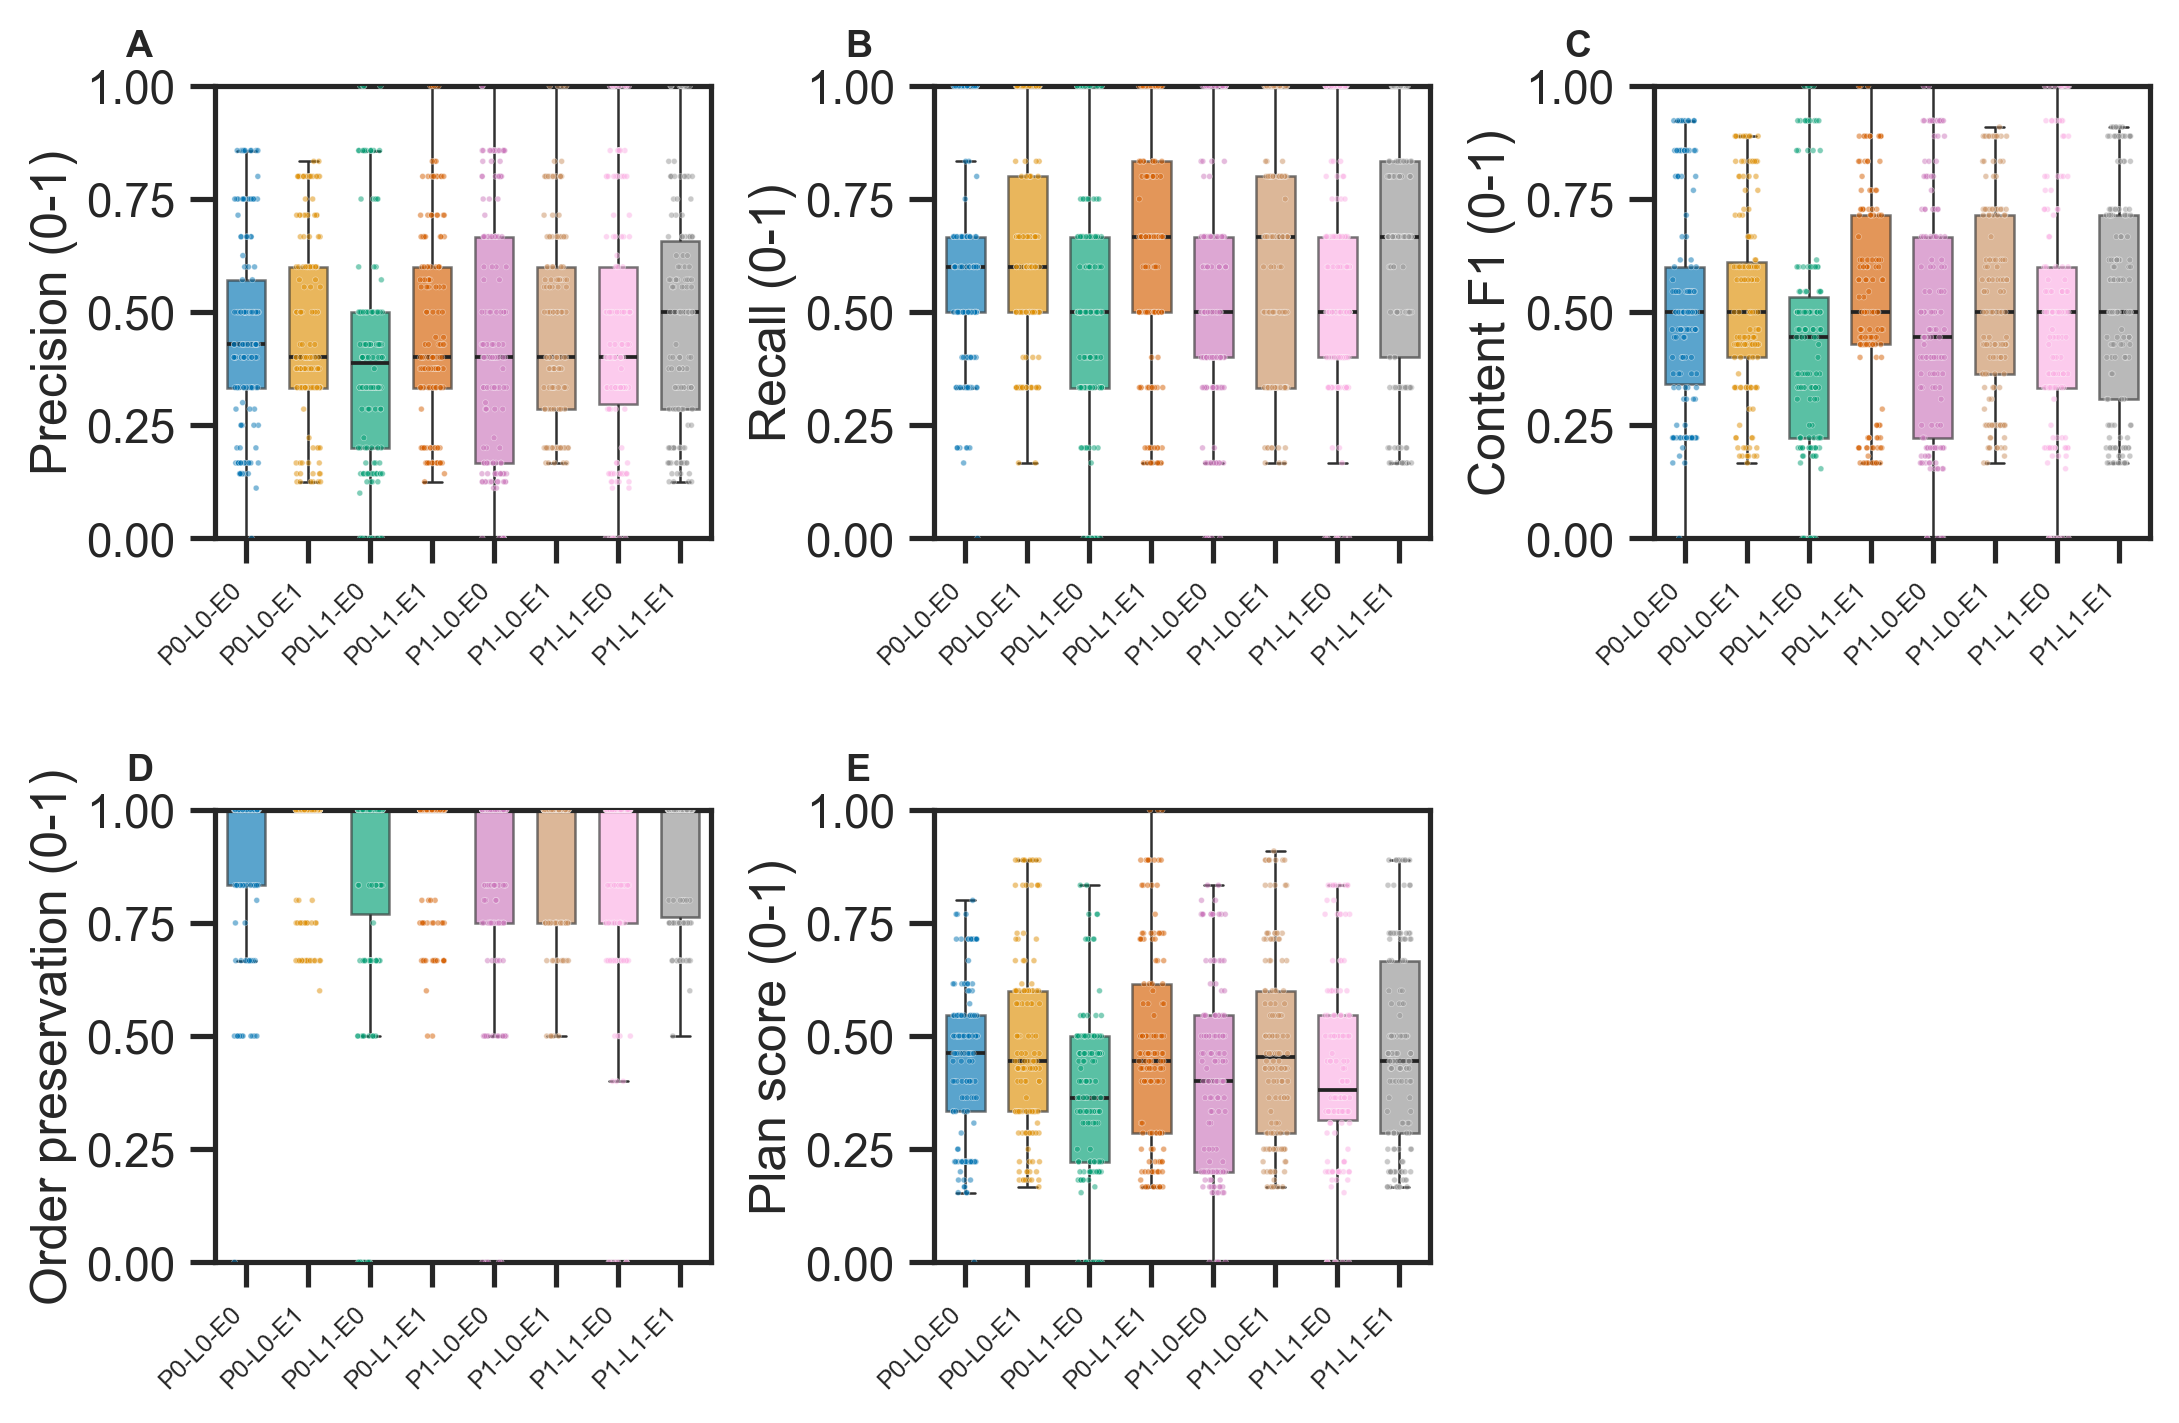

In [11]:
metrics = ["precision", "recall", "content_f1", "order_preservation", "plan_score"]
metric_labels = {
    "precision": "Precision (0-1)",
    "recall": "Recall (0-1)",
    "content_f1": "Content F1 (0-1)",
    "order_preservation": "Order preservation (0-1)",
    "plan_score": "Plan score (0-1)",
}

W_MM, H_MM = 183, 120
fig, axes = plt.subplots(2, 3, figsize=(W_MM / 25.4, H_MM / 25.4))
fig.subplots_adjust(left=0.08, right=0.975, top=0.95, bottom=0.12, hspace=0.6, wspace=0.45)

for ax, metric, panel in zip(axes.flat, metrics, "ABCDE"):
    sns.boxplot(
        data=scores_df, x="config", y=metric, order=CONFIG_ORDER, hue="config",
        palette=CONFIG_COLORS, saturation=1.0, width=0.62, linewidth=0.6, fliersize=0,
        boxprops=dict(alpha=0.65), medianprops=dict(color="#222222", linewidth=0.9),
        whiskerprops=dict(linewidth=0.6), capprops=dict(linewidth=0.6), legend=False, ax=ax,
    )
    sns.stripplot(
        data=scores_df, x="config", y=metric, order=CONFIG_ORDER, hue="config",
        palette=CONFIG_COLORS, size=1.4, alpha=0.5, edgecolor="white", linewidth=0.15,
        jitter=0.2, legend=False, ax=ax,
    )
    ax.set_xticklabels(CONFIG_ORDER, rotation=45, ha="right", fontsize=6)
    ax.set_xlabel("")
    ax.set_ylabel(metric_labels[metric], labelpad=2)
    ax.set_ylim(0, 1)
    ax.text(-0.18, 1.05, panel, transform=ax.transAxes, fontsize=9, fontweight="bold",
            va="bottom", ha="left")

axes.flat[-1].set_visible(False)
fig.savefig(OUTPUT_DIR / "fig_metric_distributions.svg")
fig.savefig(OUTPUT_DIR / "fig_metric_distributions.png", dpi=300)
plt.show()

## 11. Mean PlanScore by configuration (95% CI)

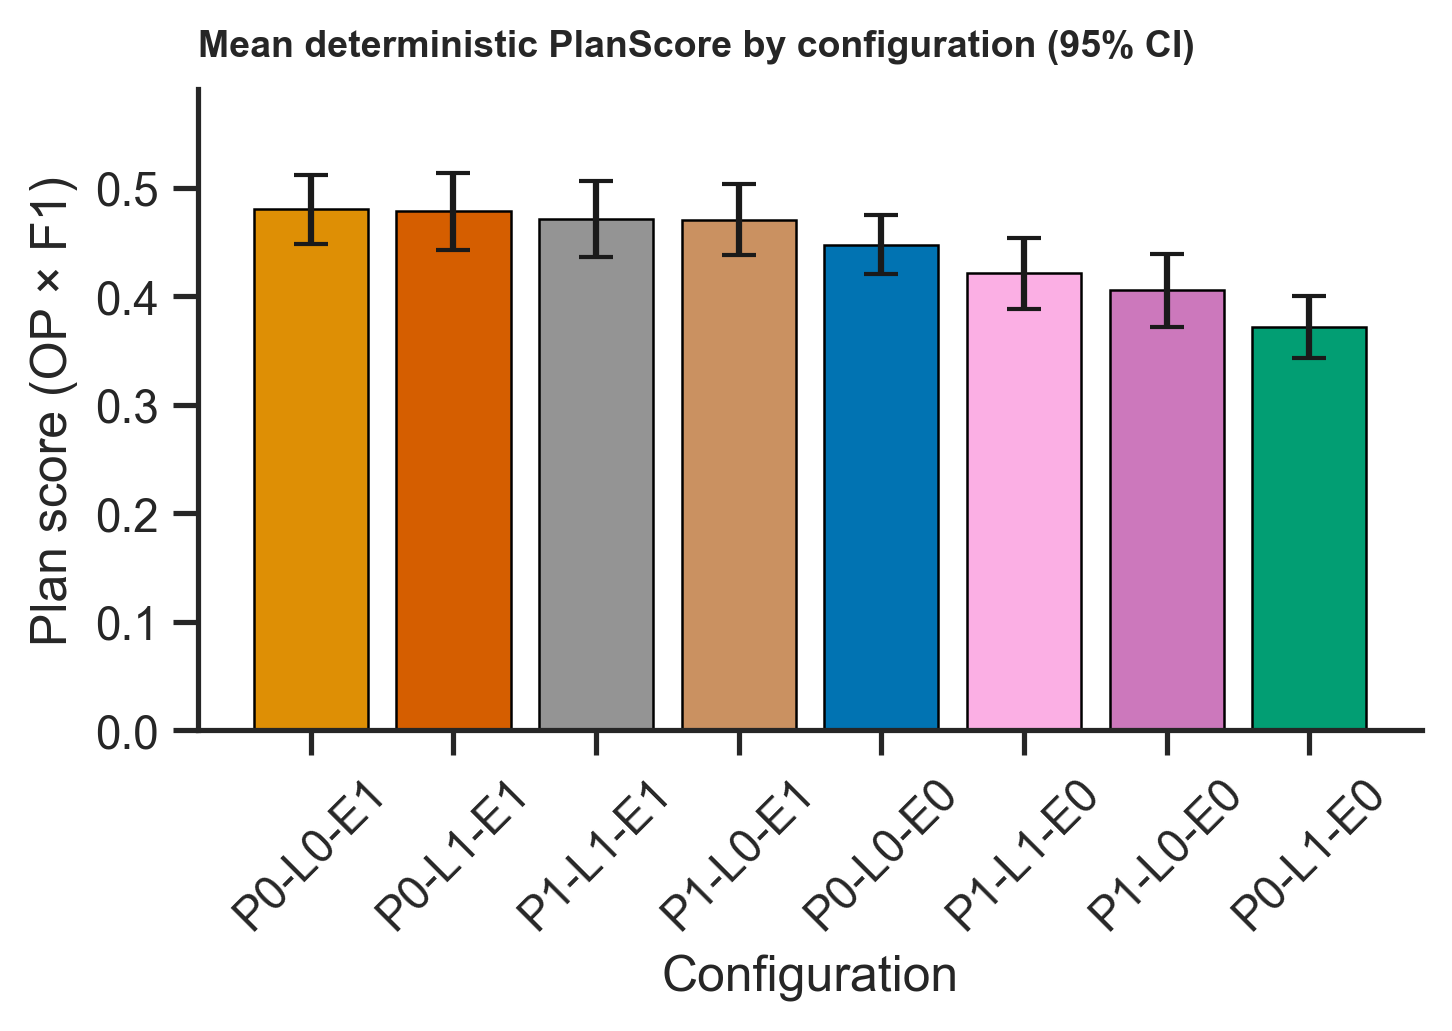

In [12]:
fig, ax = plt.subplots(figsize=(5.0, 3.6))
ordered = summary_df.sort_values("plan_score", ascending=False)
ax.bar(
    ordered["config"].astype(str), ordered["plan_score"],
    yerr=ordered["plan_score_ci95"], capsize=4,
    color=[CONFIG_COLORS[c] for c in ordered["config"]], edgecolor="black", linewidth=0.6,
)
ax.set_ylabel("Plan score (OP × F1)")
ax.set_xlabel("Configuration")
ax.set_title("Mean deterministic PlanScore by configuration (95% CI)",
             fontsize=9, fontweight="bold", loc="left", pad=8)
ax.tick_params(axis="x", rotation=45)
ax.set_ylim(0, max(ordered["plan_score"] + ordered["plan_score_ci95"]) * 1.15)
sns.despine()
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "fig_planscore_bars.svg")
fig.savefig(OUTPUT_DIR / "fig_planscore_bars.png", dpi=300)
plt.show()

## 12. Pairwise significance heatmap (Holm-adjusted)

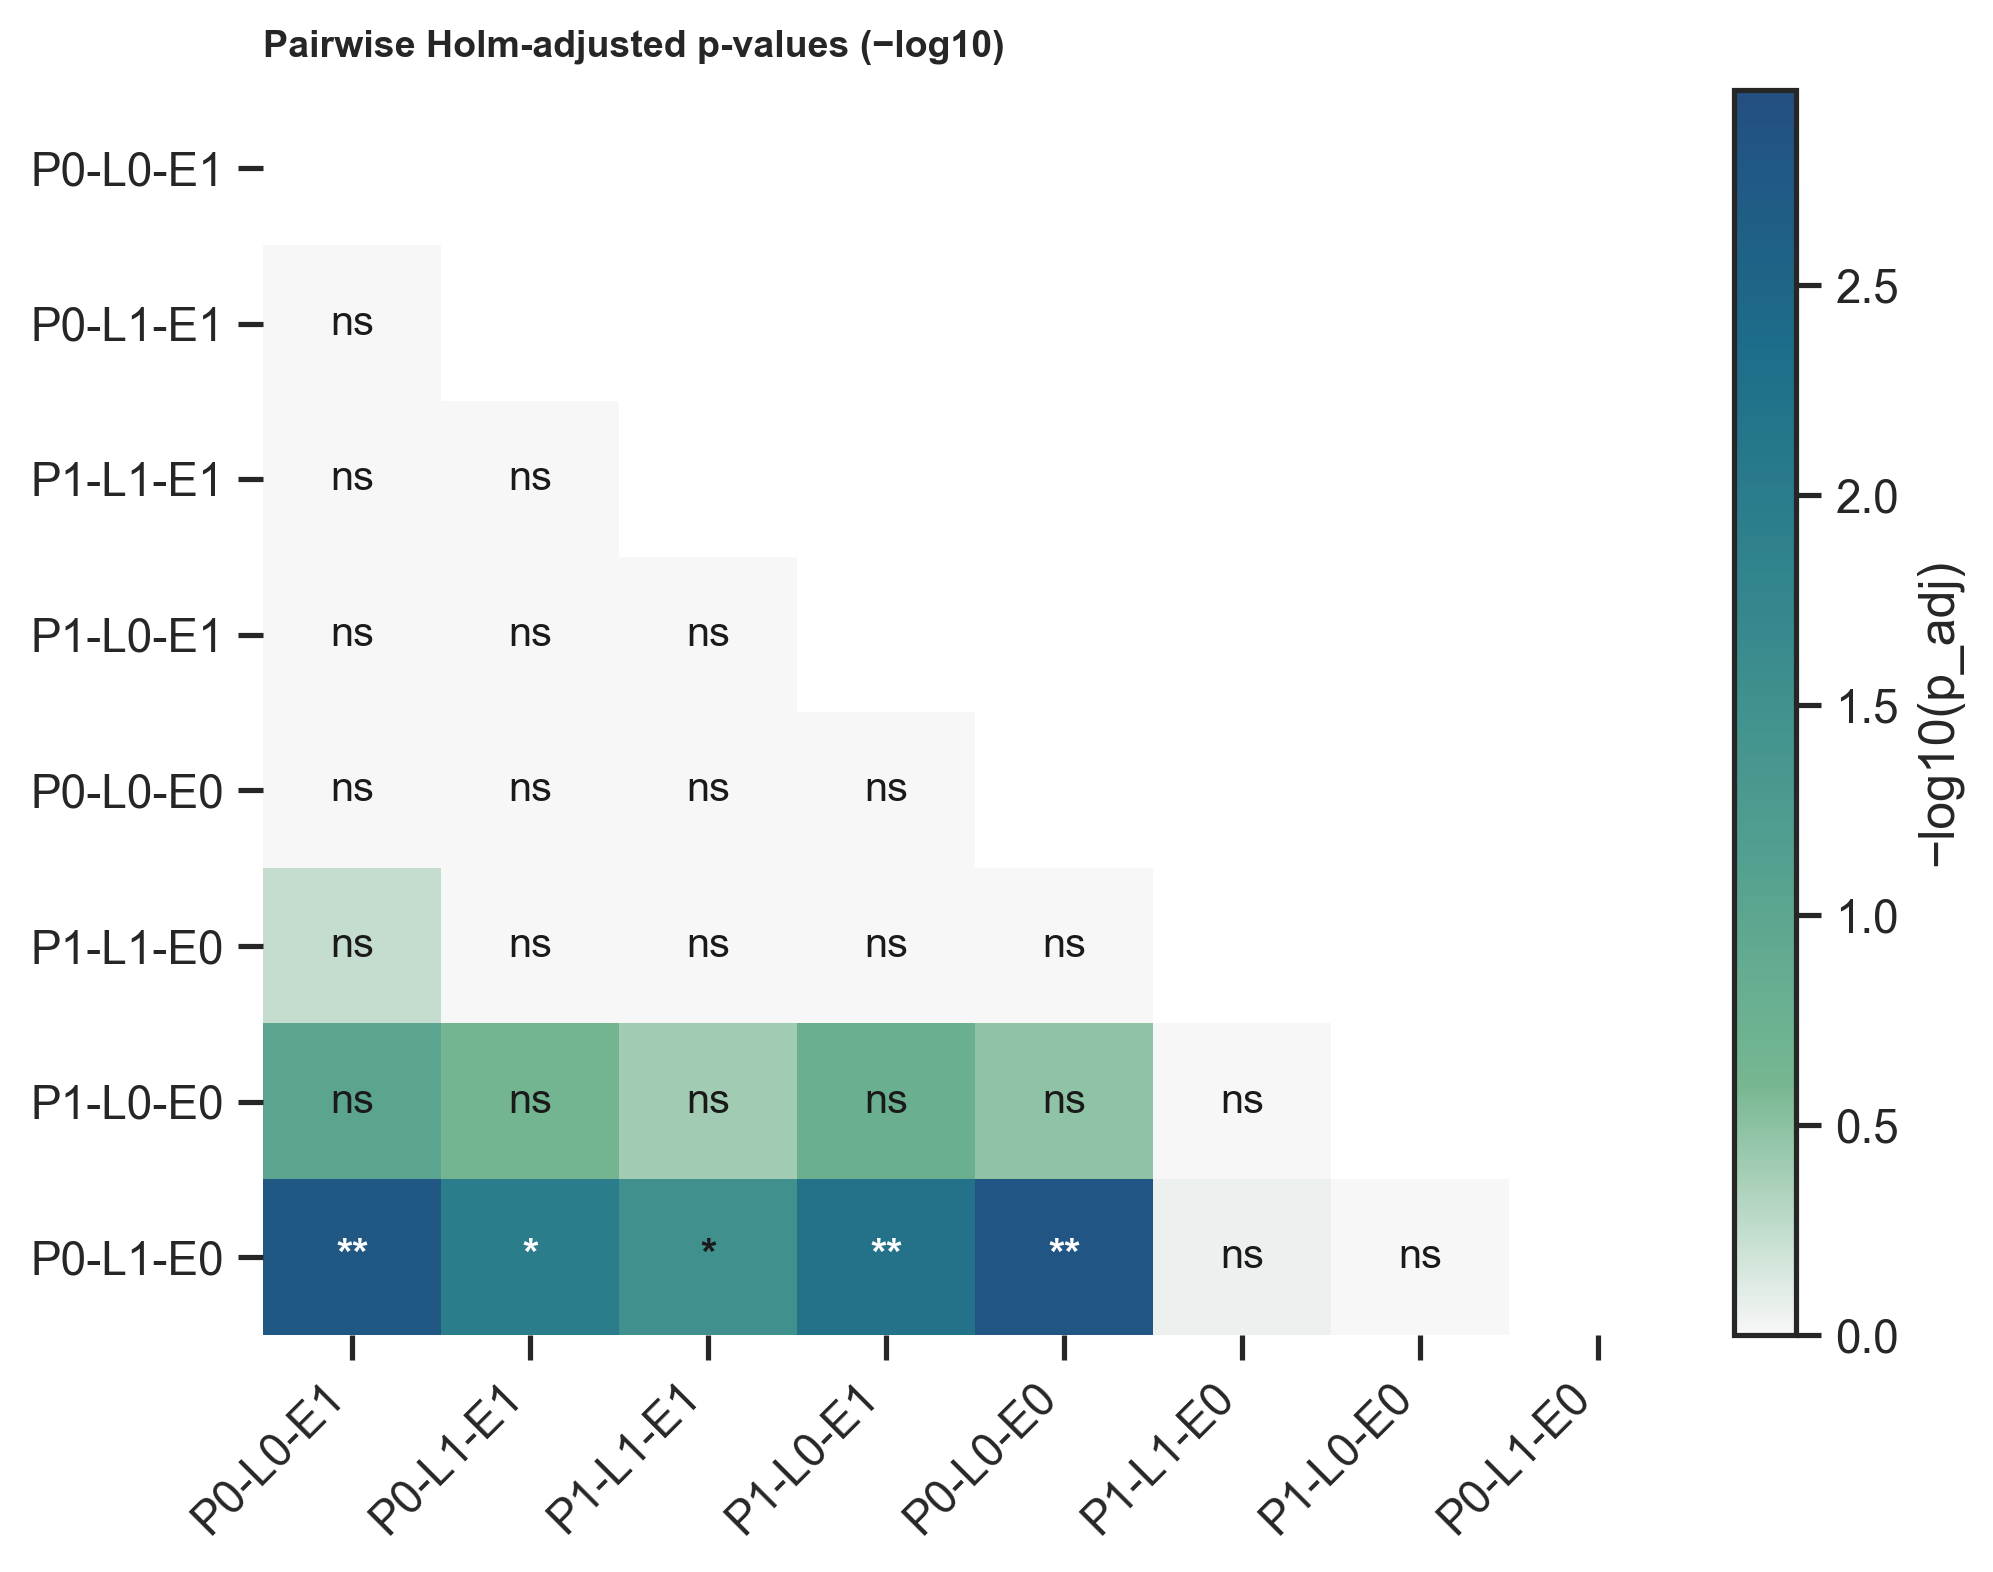

In [13]:
from matplotlib.colors import LinearSegmentedColormap


def p_to_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"


order = summary_df.sort_values("plan_score", ascending=False)["config"].astype(str).tolist()
n = len(order)
pos = {c: i for i, c in enumerate(order)}
p_mat = np.full((n, n), np.nan)
for row in pairwise_df.itertuples(index=False):
    i, j = pos[row.config_a], pos[row.config_b]
    p_mat[i, j] = p_mat[j, i] = row.p_adj

with np.errstate(divide="ignore"):
    log_p = -np.log10(p_mat)
lower = np.where(np.tril(np.ones((n, n), dtype=bool), k=-1), log_p, np.nan)

cmap = LinearSegmentedColormap.from_list(
    "pval", ["#F7F7F7"] + sns.color_palette("crest", n_colors=5).as_hex(), N=256)
cmap.set_bad("white")

fig, ax = plt.subplots(figsize=(6.8, 5.4))
vmax = np.nanmax(log_p) * 1.05 if np.isfinite(np.nanmax(log_p)) else 1.0
im = ax.imshow(lower, cmap=cmap, aspect="auto", vmin=0, vmax=vmax, interpolation="nearest")

for i in range(n):
    for j in range(n):
        if j >= i or np.isnan(p_mat[i, j]):
            continue
        txt = p_to_stars(p_mat[i, j])
        color = "white" if log_p[i, j] > vmax * 0.55 else "#1a1a1a"
        ax.text(j, i, txt, ha="center", va="center", fontsize=10, color=color,
                fontweight="bold" if txt != "ns" else "normal")

ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(order, rotation=45, ha="right")
ax.set_yticklabels(order)
ax.set_title("Pairwise Holm-adjusted p-values (−log10)", fontsize=9, fontweight="bold", loc="left", pad=8)
cbar = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.03)
cbar.set_label("−log10(p_adj)")
ax.grid(False)
sns.despine(left=True, bottom=True)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "fig_pairwise_heatmap.svg")
fig.savefig(OUTPUT_DIR / "fig_pairwise_heatmap.png", dpi=300)
plt.show()